<a href="https://colab.research.google.com/github/ashrafsohail42003/Training-project/blob/main/LogReg%2C_Random_Forest%2C_or_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    make_scorer,
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Pre


In [21]:
path = '/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week07/Data/stroke.csv'
df = pd.read_csv(path)
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0
5,57210,Female,28,0,0,Yes,Private,Rural,131.80,30.3,never smoked,0
6,61103,Female,64,1,0,Yes,Self-employed,Urban,190.92,31.4,never smoked,0
7,6480,Male,62,0,0,No,Govt_job,Urban,93.55,31.7,never smoked,0
8,62983,Female,26,0,0,Yes,Private,Urban,138.02,20.3,smokes,0
9,50784,Male,63,0,0,Yes,Private,Rural,228.56,27.4,never smoked,1


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


In [23]:
print(df['stroke'].value_counts(normalize=True).round(4))
print(df['stroke'].value_counts())

print("\n=== CATEGORICAL DISTRIBUTIONS ===")
for col in ['gender', 'hypertension', 'heart_disease',
            'work_type', 'Residence_type', 'smoking_status']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True).round(4))

stroke
0    0.8795
1    0.1205
Name: proportion, dtype: float64
stroke
0    1000
1     137
Name: count, dtype: int64

=== CATEGORICAL DISTRIBUTIONS ===

--- gender ---
gender
Female    0.5646
Male      0.4345
Other     0.0009
Name: proportion, dtype: float64

--- hypertension ---
hypertension
0    0.8813
1    0.1187
Name: proportion, dtype: float64

--- heart_disease ---
heart_disease
0    0.9314
1    0.0686
Name: proportion, dtype: float64

--- work_type ---
work_type
Private          0.5910
Self-employed    0.1530
children         0.1293
Govt_job         0.1249
Never_worked     0.0018
Name: proportion, dtype: float64

--- Residence_type ---
Residence_type
Urban    0.5163
Rural    0.4837
Name: proportion, dtype: float64

--- smoking_status ---
smoking_status
never smoked       0.3659
Unknown            0.3096
formerly smoked    0.1803
smokes             0.1442
Name: proportion, dtype: float64


In [24]:
df = df.drop(columns=['id'])
df['smoking_status'] = df['smoking_status'].replace('Unknown', np.nan)
df = df[df['gender'] != 'Other']
df = df[df['work_type'] != 'Never_worked']

for col in ['age', 'avg_glucose_level', 'bmi']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape after cleaning: {df.shape}")
print(f"Missing values:\n{df.isna().sum()}")

Shape after cleaning: (1134, 11)
Missing values:
gender                 0
age                    1
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                   52
smoking_status       350
stroke                 0
dtype: int64


In [25]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [26]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numerical_cols   = ['age', 'avg_glucose_level', 'bmi','hypertension', 'heart_disease']

In [27]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

In [28]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

In [29]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols),
])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train stroke rate: {y_train.mean():.4f}")
print(f"Test  stroke rate: {y_test.mean():.4f}")

Train: (907, 10) | Test: (227, 10)
Train stroke rate: 0.1213
Test  stroke rate: 0.1189


In [31]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8, 4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
    report = classification_report(y_true, y_pred)
    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=None, cmap='gist_gray',
        colorbar=colorbar, ax=axes[0],
    )
    axes[0].set_title("Raw Counts")

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=normalize, cmap=cmap,
        colorbar=colorbar, ax=axes[1],
    )
    axes[1].set_title("Normalized Confusion Matrix")

    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(8, 4), normalize='true',
                            output_dict=False,
                            cmap_train='Blues', cmap_test='Reds',
                            colorbar=False):
    """Evaluates a fitted classifier on train AND test data."""
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(
        y_train, y_train_pred,
        label='Training Data',
        output_dict=True,
        figsize=figsize, normalize=normalize,
        cmap=cmap_train, colorbar=colorbar,
    )

    print()

    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(
        y_test, y_test_pred,
        label='Test Data',
        output_dict=True,
        figsize=figsize, normalize=normalize,
        cmap=cmap_test, colorbar=colorbar,
    )

    if output_dict:
        return {'train': results_train, 'test': results_test}

# New Section

# New Section

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.98      0.94       797
           1       0.56      0.16      0.25       110

    accuracy                           0.88       907
   macro avg       0.73      0.57      0.60       907
weighted avg       0.85      0.88      0.85       907



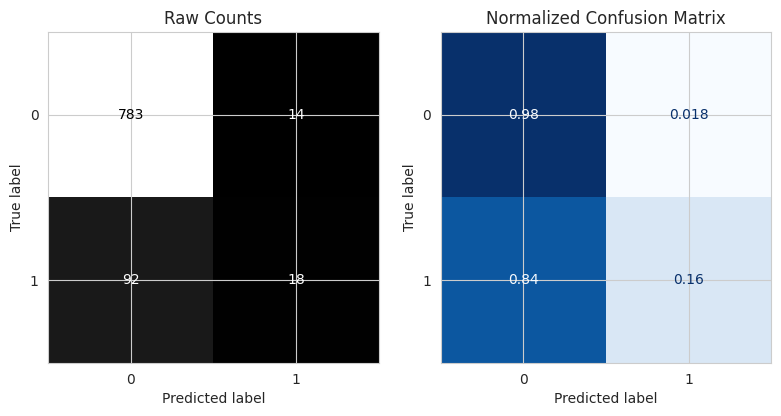


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       200
           1       0.25      0.11      0.15        27

    accuracy                           0.85       227
   macro avg       0.57      0.53      0.54       227
weighted avg       0.81      0.85      0.83       227



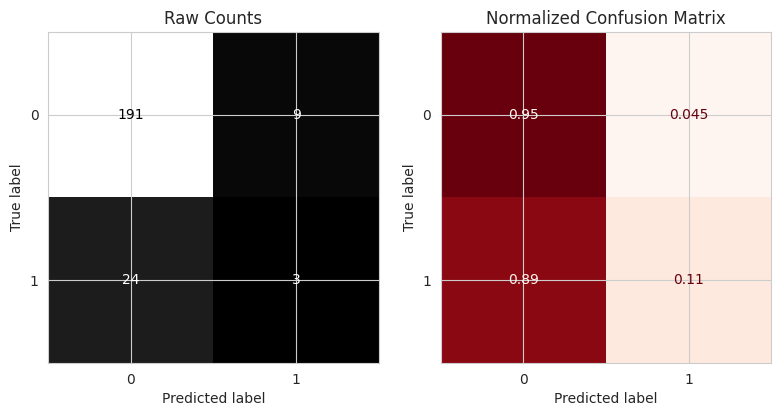

In [32]:
log_reg_default = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

log_reg_default.fit(X_train, y_train)

results_logreg_default = evaluate_classification(
    log_reg_default, X_train, y_train, X_test, y_test,
    output_dict=True,
)

In [33]:
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
param_grid = [
    {
        'classifier__solver':       ['liblinear'],
        'classifier__penalty':      ['l1', 'l2'],
        'classifier__C':            C_values,
        'classifier__class_weight': ['balanced', None],
    },
    {
        'classifier__solver':       ['lbfgs'],
        'classifier__penalty':      ['l2'],
        'classifier__C':            C_values,
        'classifier__class_weight': ['balanced', None],
    },
    {
        'classifier__solver':       ['saga'],
        'classifier__penalty':      ['elasticnet'],
        'classifier__l1_ratio':     [0.1, 0.3, 0.5, 0.7, 0.9],
        'classifier__class_weight': ['balanced', None],
    },
]

cv_logreg = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

log_reg_grid = GridSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
        )),
    ]),
    param_grid=param_grid,
    scoring='recall_macro',
    cv=cv_logreg,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    refit=True,
)

log_reg_grid.fit(X_train, y_train)

print("=" * 70)
print(f"Best CV recall_macro: {log_reg_grid.best_score_:.4f}")
print("Best parameters:")
for k, v in log_reg_grid.best_params_.items():
    print(f"  {k:<35} = {v}")
print("=" * 70)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best CV recall_macro: 0.7685
Best parameters:
  classifier__class_weight            = balanced
  classifier__l1_ratio                = 0.9
  classifier__penalty                 = elasticnet
  classifier__solver                  = saga


  TUNED LOGISTIC REGRESSION — Best parameters from GridSearchCV
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.74      0.84       797
           1       0.30      0.83      0.44       110

    accuracy                           0.75       907
   macro avg       0.64      0.78      0.64       907
weighted avg       0.89      0.75      0.79       907



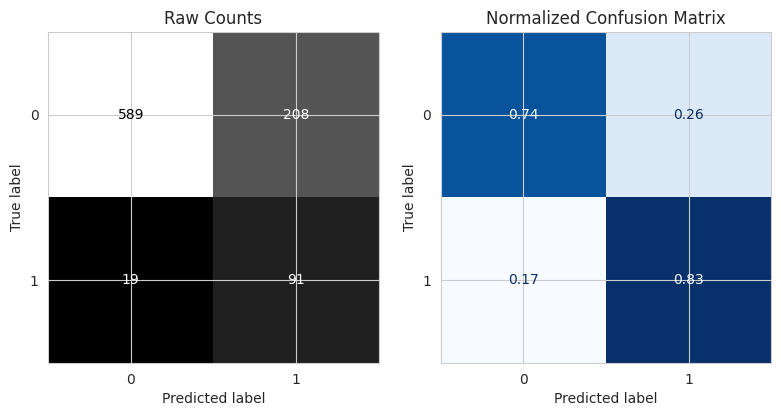


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.69      0.80       200
           1       0.27      0.85      0.41        27

    accuracy                           0.70       227
   macro avg       0.62      0.77      0.61       227
weighted avg       0.89      0.70      0.76       227



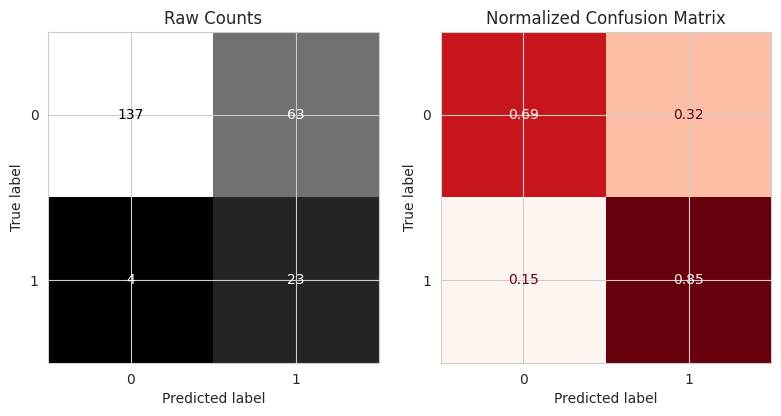

In [34]:
print("=" * 72)
print("  TUNED LOGISTIC REGRESSION — Best parameters from GridSearchCV")
print("=" * 72)

results_logreg_tuned = evaluate_classification(
    log_reg_grid.best_estimator_,
    X_train, y_train, X_test, y_test,
    output_dict=True,
)

In [35]:
# Side-by-side comparison: Default vs Tuned
def extract_metrics(results, label):
    test = results['test']
    return {
        'Model': label,
        'Accuracy':            test['accuracy'],
        'Recall (Stroke)':     test['1']['recall'],
        'Precision (Stroke)':  test['1']['precision'],
        'F1 (Stroke)':         test['1']['f1-score'],
        'Macro Recall':        test['macro avg']['recall'],
        'Macro F1':            test['macro avg']['f1-score'],
    }

logreg_comparison = pd.DataFrame([
    extract_metrics(results_logreg_default, 'LogReg — Default'),
    extract_metrics(results_logreg_tuned,   'LogReg — Tuned'),
])
print("\n" + "=" * 72)
print("  LOGISTIC REGRESSION — Default vs Tuned (Test Set)")
print("=" * 72)
print(logreg_comparison.set_index('Model').round(4))


  LOGISTIC REGRESSION — Default vs Tuned (Test Set)
                  Accuracy  Recall (Stroke)  Precision (Stroke)  F1 (Stroke)  Macro Recall  Macro F1
Model                                                                                               
LogReg — Default    0.8546           0.1111              0.2500       0.1538        0.5331    0.5372
LogReg — Tuned      0.7048           0.8519              0.2674       0.4071        0.7684    0.6053


## 1d) Logistic Regression — Best Hyperparameter Combination

The GridSearchCV (3-fold CV, scoring='recall_macro') identified the following
winning combination out of 64 candidates:

| Hyperparameter   | Best Value     |
|------------------|----------------|
| `solver`         | **saga**       |
| `penalty`        | **elasticnet** |
| `l1_ratio`       | **0.9**        |
| `class_weight`   | **balanced**   |
| `C`              | 1.0 (default — not tuned with elasticnet, per task spec) |

**Best CV score (recall_macro):** 0.7685

### Performance Jump (Test Set)

| Metric                 | Default | Tuned   | Δ          |
|------------------------|---------|---------|------------|
| Accuracy               | 0.8546  | 0.7048  | -0.1498    |
| Recall (Stroke)        | 0.1111  | **0.8519** | **+0.7408** |
| Precision (Stroke)     | 0.2500  | 0.2674  | +0.0174    |
| F1 (Stroke)            | 0.1538  | 0.4071  | +0.2533    |
| **Macro Recall**       | 0.5331  | **0.7684** | **+0.2353** |

### Why this combination won

1. **`class_weight='balanced'`** — The single most impactful change.
   It re-weights the loss to penalize misclassifying the minority (Stroke)
   class proportionally to its rarity, forcing the model to actually learn
   the positive class instead of defaulting to "always No Stroke".

2. **`elasticnet` with `l1_ratio=0.9`** — Predominantly L1 regularization
   acts as automatic feature selection. With ~20+ one-hot encoded features
   and only 110 stroke samples in training, the model benefits from
   shrinking irrelevant coefficients to zero, producing a sparser and
   more robust solution than pure L2.

3. **`solver='saga'`** — The only solver that supports elasticnet penalty.
   Combined with the high `max_iter`, it converged reliably across all
   `C` and `class_weight` combinations in the grid.

### Trade-off Observed

Accuracy dropped (0.85 → 0.70) but **Recall on Stroke jumped from 11% to 85%**
— from catching 3 out of 27 stroke patients to catching 23 out of 27.
This is exactly the trade-off we want for a medical screening tool:
sacrifice some specificity to drastically reduce missed strokes (FN).


#2) k-nearest neighbors



----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       797
           1       0.72      0.30      0.42       110

    accuracy                           0.90       907
   macro avg       0.81      0.64      0.68       907
weighted avg       0.89      0.90      0.88       907



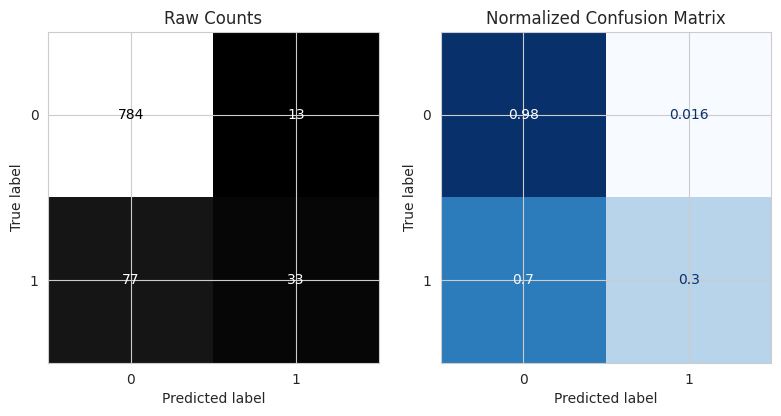


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.93      0.90       200
           1       0.17      0.11      0.13        27

    accuracy                           0.83       227
   macro avg       0.53      0.52      0.52       227
weighted avg       0.80      0.83      0.81       227



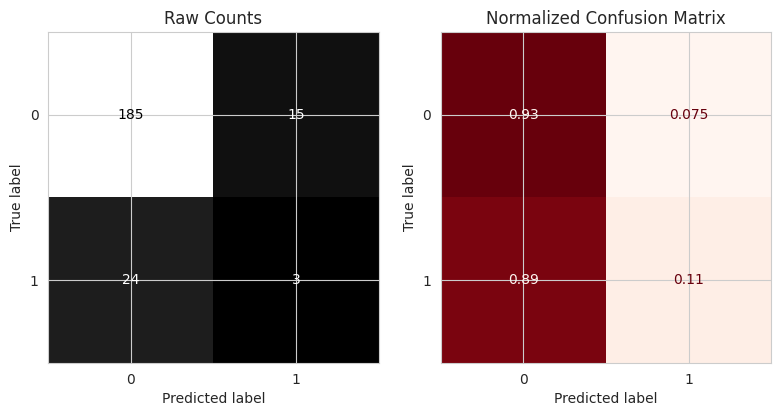

In [36]:
# ---------------------------------------------------------------
# Default KNN — baseline before tuning
# ---------------------------------------------------------------
knn_default = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   KNeighborsClassifier()),   # all defaults: n_neighbors=5, weights='uniform', metric='minkowski', p=2
])

knn_default.fit(X_train, y_train)

results_knn_default = evaluate_classification(
    knn_default, X_train, y_train, X_test, y_test,
    output_dict=True,
)

In [37]:
param_grid_knn = {
    'classifier__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 25, 31, 41],
    'classifier__weights':     ['uniform', 'distance'],
    'classifier__p':           [1, 2],          # 1 = Manhattan, 2 = Euclidean
    'classifier__metric':      ['minkowski'],   # p controls the actual distance
}

cv_knn = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

knn_grid = GridSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   KNeighborsClassifier(n_jobs=-1)),
    ]),
    param_grid=param_grid_knn,
    scoring='recall_macro',
    cv=cv_knn,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    refit=True,
)

knn_grid.fit(X_train, y_train)

print("=" * 70)
print(f"Best CV recall_macro: {knn_grid.best_score_:.4f}")
print("Best parameters:")
for k, v in knn_grid.best_params_.items():
    print(f"  {k:<35} = {v}")
print("=" * 70)

Fitting 3 folds for each of 44 candidates, totalling 132 fits
Best CV recall_macro: 0.5964
Best parameters:
  classifier__metric                  = minkowski
  classifier__n_neighbors             = 1
  classifier__p                       = 2
  classifier__weights                 = uniform


  TUNED KNN — Best parameters from GridSearchCV
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       797
           1       1.00      1.00      1.00       110

    accuracy                           1.00       907
   macro avg       1.00      1.00      1.00       907
weighted avg       1.00      1.00      1.00       907



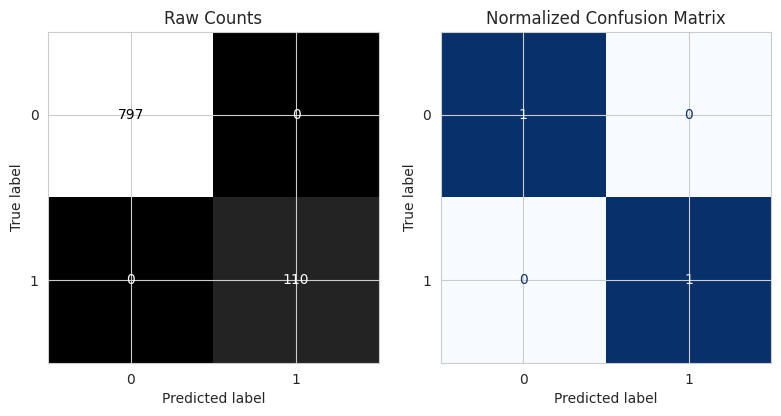


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       200
           1       0.14      0.15      0.15        27

    accuracy                           0.79       227
   macro avg       0.51      0.51      0.51       227
weighted avg       0.80      0.79      0.79       227



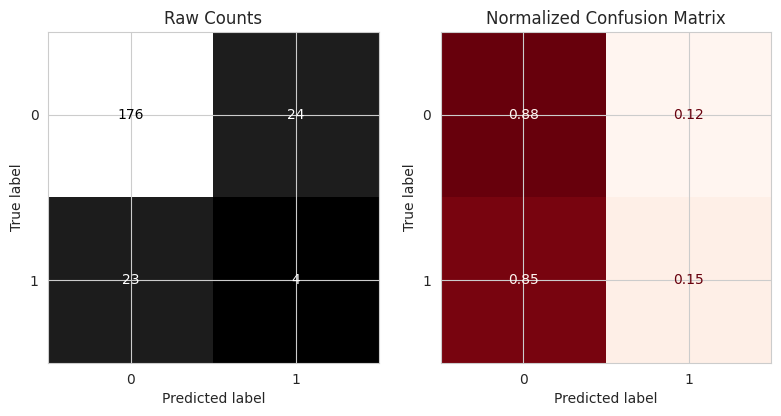

In [38]:
print("=" * 72)
print("  TUNED KNN — Best parameters from GridSearchCV")
print("=" * 72)

results_knn_tuned = evaluate_classification(
    knn_grid.best_estimator_,
    X_train, y_train, X_test, y_test,
    output_dict=True,
)

In [39]:
knn_comparison = pd.DataFrame([
    extract_metrics(results_knn_default, 'KNN — Default'),
    extract_metrics(results_knn_tuned,   'KNN — Tuned'),
])
print("\n" + "=" * 72)
print("  KNN — Default vs Tuned (Test Set)")
print("=" * 72)
print(knn_comparison.set_index('Model').round(4))


  KNN — Default vs Tuned (Test Set)
               Accuracy  Recall (Stroke)  Precision (Stroke)  F1 (Stroke)  Macro Recall  Macro F1
Model                                                                                            
KNN — Default    0.8282           0.1111              0.1667       0.1333        0.5181    0.5190
KNN — Tuned      0.7930           0.1481              0.1429       0.1455        0.5141    0.5138


In [40]:
print(knn_grid.best_params_)
print(f"Best CV score: {knn_grid.best_score_:.4f}")

{'classifier__metric': 'minkowski', 'classifier__n_neighbors': 1, 'classifier__p': 2, 'classifier__weights': 'uniform'}
Best CV score: 0.5964


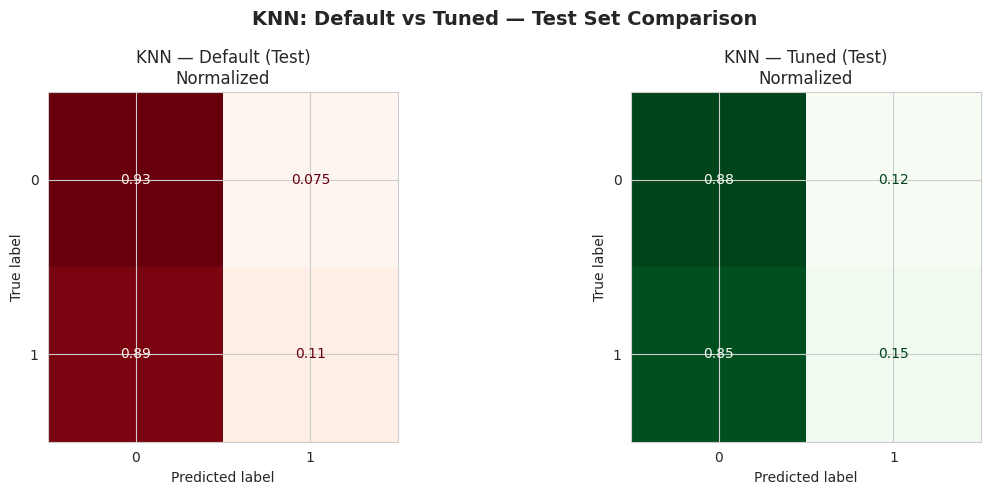

  KNN — Default vs Tuned (Test Set Metrics)
               Accuracy  Recall (Stroke)  Precision (Stroke)  F1 (Stroke)  Macro Recall  Macro F1
Model                                                                                            
KNN — Default    0.8282           0.1111              0.1667       0.1333        0.5181    0.5190
KNN — Tuned      0.7930           0.1481              0.1429       0.1455        0.5141    0.5138


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    knn_default, X_test, y_test,
    normalize='true', cmap='Reds',
    colorbar=False, ax=axes[0],
)
axes[0].set_title("KNN — Default (Test)\nNormalized", fontsize=12)

ConfusionMatrixDisplay.from_estimator(
    knn_grid.best_estimator_, X_test, y_test,
    normalize='true', cmap='Greens',
    colorbar=False, ax=axes[1],
)
axes[1].set_title("KNN — Tuned (Test)\nNormalized", fontsize=12)

fig.suptitle("KNN: Default vs Tuned — Test Set Comparison",
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


print("=" * 72)
print("  KNN — Default vs Tuned (Test Set Metrics)")
print("=" * 72)
print(knn_comparison.set_index('Model').round(4))

## KNN Model — Tuning Discussion

The best KNN model from GridSearchCV used the following hyperparameters:

- **n_neighbors:** 1
- **weights:** uniform
- **p:** 2 (Euclidean distance)
- **metric:** minkowski

This combination produced a cross-validated `recall_macro` of **0.5964**, but only **0.5141** on the test set.

Honestly, the tuning didn't really help. The model picked `n_neighbors=1`, which means it's basically memorizing the training data instead of learning a real pattern. That's why the test performance dropped compared to the cross-validation score — classic overfitting.

The default KNN already had a test recall of **0.11** for the stroke class, and the tuned version only nudged it to **0.15**, which is still very weak. The main reason is that KNN doesn't have a `class_weight` parameter, so it can't compensate for the heavy class imbalance (88% no stroke vs 12% stroke). Most of the neighbors around any given point are non-stroke cases, so the model keeps voting "no stroke" by default.

Overall, **KNN is not a good fit for this problem**. We'll see if Random Forest does better.

# 3) Random Forest

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       797
           1       1.00      1.00      1.00       110

    accuracy                           1.00       907
   macro avg       1.00      1.00      1.00       907
weighted avg       1.00      1.00      1.00       907



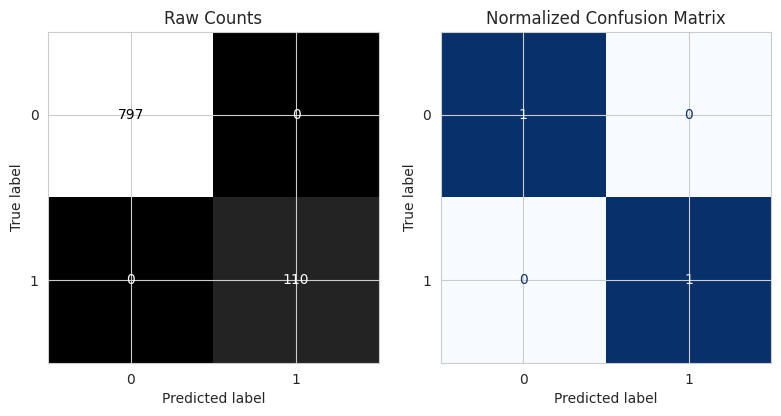


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       200
           1       0.09      0.04      0.05        27

    accuracy                           0.84       227
   macro avg       0.49      0.49      0.48       227
weighted avg       0.79      0.84      0.81       227



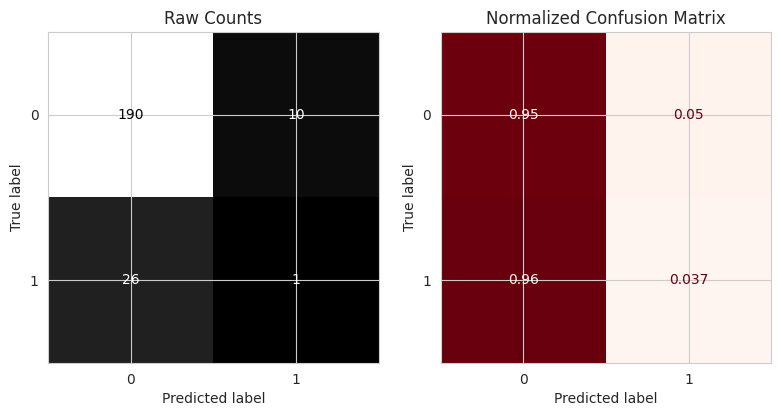

In [42]:
rf_default = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_default.fit(X_train, y_train)

results_rf_default = evaluate_classification(
    rf_default, X_train, y_train, X_test, y_test,
    output_dict=True,
)

In [43]:
param_grid_rf = {
    'classifier__n_estimators':      [200, 400],
    'classifier__max_depth':         [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf':  [1, 2, 4],
    'classifier__max_features':      ['sqrt', 'log2'],
    'classifier__class_weight':      ['balanced', 'balanced_subsample', None],
}

cv_rf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_grid = GridSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    param_grid=param_grid_rf,
    scoring='recall_macro',
    cv=cv_rf,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    refit=True,
)

rf_grid.fit(X_train, y_train)

print("=" * 70)
print(f"Best CV recall_macro: {rf_grid.best_score_:.4f}")
print("Best parameters:")
for k, v in rf_grid.best_params_.items():
    print(f"  {k:<40} = {v}")
print("=" * 70)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best CV recall_macro: 0.7438
Best parameters:
  classifier__class_weight                 = balanced_subsample
  classifier__max_depth                    = 5
  classifier__max_features                 = sqrt
  classifier__min_samples_leaf             = 4
  classifier__min_samples_split            = 10
  classifier__n_estimators                 = 200


The best Random Forest model from GridSearchCV used the following hyperparameters:

- **n_estimators:** 200
- **max_depth:** 5
- **min_samples_split:** 10
- **min_samples_leaf:** 4
- **max_features:** sqrt
- **class_weight:** balanced_subsample

This combination produced a cross-validated `recall_macro` of **0.7438**.

The tuning made a clear difference here. The default Random Forest was heavily overfitted (perfect training scores but only 0.04 recall for stroke on test). The tuned version used `max_depth=5`, `min_samples_leaf=4`, and `min_samples_split=10` to keep the trees shallow and prevent memorization, while `class_weight='balanced_subsample'` re-weighted each tree's bootstrap sample to handle the 88/12 class imbalance.

Together, these settings shifted the model from "memorize training data" to "learn generalizable patterns," which is exactly what we needed for this imbalanced dataset.